# Story A: Taste Tribes — User Segmentation via Clustering

**Module:** Story A | **Methods:** K-Means, Silhouette, t-SNE, PCA  
**Author:** Vĩnh Hoàng | **Course:** Data Mining — MSA30DN, FSB  
**Instructor:** PhD. Cao Vu BUI

---

## Mục tiêu nghiên cứu

Phân nhóm người dùng MovieLens thành các **"Taste Tribes"** (bộ tộc sở thích) dựa trên hành vi đánh giá phim.  
Câu hỏi cốt lõi: *Có những nhóm người dùng có sở thích tương đồng và khác biệt rõ rệt không?*

## Luồng xử lý

```
user_features_train.parquet
        │
        ▼
  1. Load & Inspect
        │
        ▼
  2. Preprocessing (fillna, log-transform, StandardScaler)
        │
        ▼
  3. K Sweep (Silhouette + Elbow) → Chọn K tối ưu
        │
        ▼
  4. K-Means Clustering
        │
        ▼
  5. Visualizations (t-SNE, PCA 3D, Radar Chart)
        │
        ▼
  6. Evaluation (Silhouette, Davies-Bouldin, Calinski-Harabasz, Inertia)
        │
        ▼
  7. Export Artifacts → artifacts/story_A/
```

## 0. Imports & Setup

In [2]:
import os
import json
import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from plotly.subplots import make_subplots

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
)

# ── FIX PLOTLY RENDERER CHO VS CODE ──────────────────────────────────────────
# 'vscode' là renderer native cho VS Code. 
# Nếu vẫn thỉnh thoảng thấy trắng xoá, hãy đổi thành 'iframe_connected'
pio.renderers.default = 'vscode' 

# ── Paths ──────────────────────────────────────────────────────────────────────
DATA_DIR    = 'data-warehousing'
STORY_A_DIR = os.path.join('artifacts', 'story_A')
TABLES_OUT  = os.path.join(STORY_A_DIR, 'tables')
REPORTS_OUT = os.path.join(STORY_A_DIR, 'reports')
FIGURES_OUT = os.path.join(STORY_A_DIR, 'figures')

for d in [TABLES_OUT, REPORTS_OUT, FIGURES_OUT]:
    os.makedirs(d, exist_ok=True)

RANDOM_STATE = 42
print('✅ Setup OK - Plotly is ready for VS Code')


✅ Setup OK - Plotly is ready for VS Code


## 1. Load Data

In [3]:
features_path     = os.path.join(DATA_DIR, 'user_features_train.parquet')
movies_path       = os.path.join(DATA_DIR, 'dim_movies_clean.parquet')
interactions_path = os.path.join(DATA_DIR, 'interactions_train.parquet')

df_features    = pd.read_parquet(features_path)
df_movies      = pd.read_parquet(movies_path)       if os.path.exists(movies_path)       else None
df_interactions= pd.read_parquet(interactions_path) if os.path.exists(interactions_path) else None

print(f'User features shape   : {df_features.shape}')
print(f'Movies shape          : {df_movies.shape if df_movies is not None else "N/A"}')
print(f'Interactions shape    : {df_interactions.shape if df_interactions is not None else "N/A"}')
df_features.head(3)

User features shape   : (322397, 29)
Movies shape          : (86537, 5)
Interactions shape    : (30296556, 5)


,userId,n_ratings,rating_mean,rating_std,rating_min,rating_max,first_dt,last_dt,active_days,n_tag_events,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
0,1,55,3.990909,0.754560,2.0,5.0,2008-11-03 17:31:43+00:00,2008-11-03 18:35:15+00:00,1,0,...,0.0,4.166667,3.000000,3.833333,4.00,4.107143,3.500000,3.750000,4.666667,0.00
1,2,81,3.506173,1.073819,1.0,5.0,1996-06-26 18:59:11+00:00,1996-06-26 19:19:26+00:00,1,0,...,0.0,3.500000,4.333333,3.500000,3.25,3.666667,2.666667,3.428571,4.500000,3.75
2,3,27,4.888889,0.423659,3.0,5.0,2018-09-05 18:57:20+00:00,2018-09-05 19:04:04+00:00,1,0,...,0.0,5.000000,5.000000,0.000000,5.00,5.000000,4.400000,4.875000,5.000000,5.00


In [4]:
# Kiểm tra thông tin cột
print('Columns:', df_features.columns.tolist())
print('\nNull counts:')
print(df_features.isnull().sum()[df_features.isnull().sum() > 0])
print('\nBasic stats:')
df_features.describe()

Columns: ['userId', 'n_ratings', 'rating_mean', 'rating_std', 'rating_min', 'rating_max', 'first_dt', 'last_dt', 'active_days', 'n_tag_events', 'genre_pref__action', 'genre_pref__adventure', 'genre_pref__animation', 'genre_pref__children', 'genre_pref__comedy', 'genre_pref__crime', 'genre_pref__documentary', 'genre_pref__drama', 'genre_pref__fantasy', 'genre_pref__film_noir', 'genre_pref__horror', 'genre_pref__imax', 'genre_pref__musical', 'genre_pref__mystery', 'genre_pref__romance', 'genre_pref__sci_fi', 'genre_pref__thriller', 'genre_pref__war', 'genre_pref__western']

Null counts:
Series([], dtype: int64)

Basic stats:


,userId,n_ratings,rating_mean,rating_std,rating_min,rating_max,active_days,n_tag_events,genre_pref__action,genre_pref__adventure,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
count,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,...,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000,322397.000000
mean,165454.746741,93.972822,3.686650,0.892114,1.702248,4.863373,5.236398,6.013787,3.370104,3.313867,...,1.048234,2.371325,2.059974,2.035021,2.840405,3.280210,3.142891,3.393597,2.758117,1.714013
std,95551.098004,211.165123,0.600691,0.350442,1.130649,0.399043,36.577174,1082.934948,1.105175,1.204086,...,1.779977,1.784695,1.975288,1.882792,1.756577,1.317587,1.362593,1.156171,1.893044,1.918879
min,1.000000,1.000000,0.500000,0.000000,0.500000,0.500000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,82728.000000,13.000000,3.351351,0.692292,1.000000,5.000000,1.000000,0.000000,3.000000,3.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,3.000000,2.867647,3.125000,0.000000,0.000000
50%,165453.000000,29.000000,3.714286,0.882766,1.000000,5.000000,1.000000,0.000000,3.577519,3.584302,...,0.000000,3.000000,2.666667,2.614286,3.500000,3.625000,3.500000,3.647059,3.600000,0.000000
75%,248188.000000,90.000000,4.057693,1.097144,2.500000,5.000000,2.000000,0.000000,4.000000,4.000000,...,2.500000,3.888889,4.000000,3.800000,4.038462,4.000000,4.000000,4.022177,4.200000,3.666667
max,330975.000000,29998.000000,5.000000,3.181981,5.000000,5.000000,3124.000000,611796.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


## 2. Preprocessing

Các bước:
1. Loại bỏ các cột không phải đặc trưng (`userId`, `first_dt`, `last_dt`)
2. Fill NaN = 0
3. Log-transform các cột count/skewed (giảm ảnh hưởng của outlier)
4. StandardScaler (đưa về mean=0, std=1)

In [5]:
exclude_cols = ['userId', 'first_dt', 'last_dt']
feature_cols = [c for c in df_features.columns if c not in exclude_cols]

df_clean = df_features.copy()
df_clean[feature_cols] = df_clean[feature_cols].fillna(0)

# Log-transform các cột count nặng đuôi
skewed_cols = [c for c in feature_cols if 'n_ratings' in c or 'count' in c or 'n_tag' in c or 'active_days' in c]
for c in skewed_cols:
    df_clean[c] = np.log1p(df_clean[c])

scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(df_clean[feature_cols]),
    columns=feature_cols,
    index=df_clean.index
)

print(f'Feature matrix: {X_scaled.shape}')
print(f'Feature columns ({len(feature_cols)}): {feature_cols}')
X_scaled.describe()

Feature matrix: (322397, 26)
Feature columns (26): ['n_ratings', 'rating_mean', 'rating_std', 'rating_min', 'rating_max', 'active_days', 'n_tag_events', 'genre_pref__action', 'genre_pref__adventure', 'genre_pref__animation', 'genre_pref__children', 'genre_pref__comedy', 'genre_pref__crime', 'genre_pref__documentary', 'genre_pref__drama', 'genre_pref__fantasy', 'genre_pref__film_noir', 'genre_pref__horror', 'genre_pref__imax', 'genre_pref__musical', 'genre_pref__mystery', 'genre_pref__romance', 'genre_pref__sci_fi', 'genre_pref__thriller', 'genre_pref__war', 'genre_pref__western']


,n_ratings,rating_mean,rating_std,rating_min,rating_max,active_days,n_tag_events,genre_pref__action,genre_pref__adventure,genre_pref__animation,...,genre_pref__film_noir,genre_pref__horror,genre_pref__imax,genre_pref__musical,genre_pref__mystery,genre_pref__romance,genre_pref__sci_fi,genre_pref__thriller,genre_pref__war,genre_pref__western
count,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,...,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05,3.223970e+05
mean,-3.135541e-16,-2.751395e-16,-6.911547e-17,5.739052e-17,2.084263e-16,6.281221e-17,1.075521e-17,3.430428e-17,2.545547e-17,-2.250220e-17,...,-6.653686e-17,1.944424e-17,1.450852e-16,-4.434322e-17,9.150747e-17,-1.047531e-16,7.852628e-17,-2.684395e-17,-8.965616e-17,-5.993607e-17
std,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,...,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00,1.000002e+00
min,-2.131602e+00,-5.304982e+00,-2.545688e+00,-1.063327e+00,-1.093461e+01,-3.946274e-01,-2.089061e-01,-3.049390e+00,-2.752188e+00,-1.339936e+00,...,-5.889045e-01,-1.328702e+00,-1.042874e+00,-1.080854e+00,-1.617013e+00,-2.489563e+00,-2.306555e+00,-2.935208e+00,-1.456976e+00,-8.932381e-01
25%,-6.907322e-01,-5.581888e-01,-5.702032e-01,-6.211025e-01,3.423860e-01,-3.946274e-01,-2.089061e-01,-3.348832e-01,-2.606684e-01,-1.339936e+00,...,-5.889045e-01,-1.328702e+00,-1.042874e+00,-1.080854e+00,-1.047723e+00,-2.126697e-01,-2.019998e-01,-2.323165e-01,-1.456976e+00,-8.932381e-01
50%,-1.263973e-01,4.600694e-02,-2.667609e-02,-6.211025e-01,3.423860e-01,-3.946274e-01,-2.089061e-01,1.876769e-01,2.245986e-01,4.016465e-01,...,-5.889045e-01,3.522595e-01,3.071421e-01,3.076635e-01,3.755010e-01,2.616831e-01,2.620814e-01,2.192254e-01,4.447255e-01,-8.932381e-01
75%,6.952639e-01,6.176943e-01,5.850610e-01,7.055718e-01,3.423860e-01,1.539308e-01,-2.089061e-01,5.699524e-01,5.698381e-01,8.273667e-01,...,8.156105e-01,8.503223e-01,9.821501e-01,9.374281e-01,6.820417e-01,5.462948e-01,6.290294e-01,5.436749e-01,7.616757e-01,1.017603e+00
max,4.988500e+00,2.186403e+00,6.534236e+00,2.916695e+00,3.423860e-01,9.554738e+00,1.982835e+01,1.474788e+00,1.400345e+00,1.369192e+00,...,2.220126e+00,1.472901e+00,1.488406e+00,1.574780e+00,1.229436e+00,1.305259e+00,1.362925e+00,1.389419e+00,1.184276e+00,1.712454e+00


## 3. Tìm K Tối Ưu — K Sweep

Đánh giá K từ 3 đến 10 sử dụng 4 chỉ số:
| Chỉ số | Ý nghĩa | Tốt khi |
|--------|---------|--------|
| Silhouette Score | Độ gắn kết nội bộ vs. phân tách cụm | Gần +1 |
| Davies–Bouldin Index | Độ tương đồng trung bình giữa các cụm | Nhỏ → 0 |
| Calinski–Harabasz Index | Tỷ số phương sai between/within | Lớn |
| Inertia (WCSS) | Tổng bình phương khoảng cách nội cụm | Nhỏ (elbow) |

In [6]:
# Sample để đảm bảo tốc độ tính toán
SAMPLE_SIZE = min(20_000, len(X_scaled))
X_sample    = X_scaled.sample(SAMPLE_SIZE, random_state=RANDOM_STATE)

k_range    = range(3, 11)
sil_scores = []
db_scores  = []
ch_scores  = []
inertias   = []

print(f'Running K sweep on {SAMPLE_SIZE:,} samples...')
for k in k_range:
    km  = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto')
    lbl = km.fit_predict(X_sample)
    sil_scores.append(silhouette_score(X_sample, lbl, random_state=RANDOM_STATE))
    db_scores.append(davies_bouldin_score(X_sample, lbl))
    ch_scores.append(calinski_harabasz_score(X_sample, lbl))
    inertias.append(km.inertia_)
    print(f'  K={k:2d}  Sil={sil_scores[-1]:.4f}  DB={db_scores[-1]:.4f}  CH={ch_scores[-1]:.1f}  Inertia={inertias[-1]:.1f}')

best_k = list(k_range)[np.argmax(sil_scores)]
print(f'\n→ Best K by Silhouette: {best_k}')

Running K sweep on 20,000 samples...
  K= 3  Sil=0.1212  DB=2.2862  CH=3372.8  Inertia=387230.8
  K= 4  Sil=0.1148  DB=2.3036  CH=2780.1  Inertia=365435.3
  K= 5  Sil=0.1025  DB=2.2420  CH=2485.3  Inertia=345886.7
  K= 6  Sil=0.1014  DB=2.0758  CH=2230.7  Inertia=332418.8
  K= 7  Sil=0.0950  DB=2.1003  CH=2047.6  Inertia=320753.7
  K= 8  Sil=0.0987  DB=2.0429  CH=1914.6  Inertia=310024.0
  K= 9  Sil=0.0861  DB=2.0758  CH=1796.8  Inertia=301245.5
  K=10  Sil=0.0898  DB=2.0240  CH=1707.4  Inertia=292789.2

→ Best K by Silhouette: 3


### Nhận xét Khoa học & Cơ sở chọn K tối ưu (Taste Tribes)

**1. Công thức đang quyết định K là gì và ý nghĩa của nó?**
Trọng tâm đánh giá hiện đang dựa vào **Silhouette Score**. Công thức Silhouette Coefficient cho một điểm số $i$:
$$ s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))} $$
- **$a(i)$ (Cohesion):** Trung bình khoảng cách từ điểm $i$ đến các điểm khác *trong cùng một cụm*. Càng nhỏ càng tốt.
- **$b(i)$ (Separation):** Trung bình khoảng cách từ điểm $i$ đến các điểm thuộc *cụm gần nhất tiếp theo*. Càng xa càng tốt.
- Điểm dao động từ -1 đến 1. Điểm càng gần 1, cụm phân tách càng tốt. Nếu quá trình chạy mã chọn `best_k = np.argmax(sil_scores)`, tức là nó tự động lấy $K$ có trung bình Silhouette lớn nhất.

**2. Công thức Silhouette có thực sự "đúng" với bài toán này? Liệu có cách nào tốt hơn?**
Về mặt toán học K-Means, Silhouette chuẩn xác. Tuy nhiên, với Bài toán Gom cụm Hành vi Người dùng (User Behavior), điểm số tự động này thường gây nhiễu:
- **Vì sao Silhouette luôn thích $K=2$:** Dữ liệu hành vi người dùng thường không tạo thành các "khối cầu" (globular) hoàn hảo như trên lý thuyết. Sở thích xem phim chồng chéo tạo thành một đám mây khối khổng lồ. Việc "chém" đám mây đó làm 2 mảng lớn nhất (ví dụ: *User xem nhiều* vs *User xem ít*) luôn đem lại điểm Silhouette cao nhất. Nhưng điều này **vô nghĩa về mặt phân tích Insights kinh doanh**.
- **Giải pháp tốt hơn:** Thay vì phụ thuộc vào `argmax` của Silhouette, Data Scientist sử dụng **Phương pháp Khuỷu tay (Elbow Method)** bằng cách vẽ biểu đồ **Inertia (WCSS)** kết hợp quan sát Silhouette, Davies-Bouldin để chọn điểm gập lồi. Hoặc dùng các thuật toán như GMM (Gaussian Mixture Model) để bao phủ ranh giới chồng chéo.

**3. Tại sao không phân số cụm theo Cả đống thể loại phim? Tại sao đề xuất nén lại bằng 3 hay 4?**
- **Đặc trưng (Features) vs Chân dung (Clusters):** Bộ dữ liệu có khoảng 19 thể loại phim khác nhau, không gian ở đây là 19D. Nhưng chúng ta đang clustering **Người Dùng**, chứ không clustering Thể loại phim.
- Con người thường có sở thích hỗn hợp (cross-taste). Mục tiêu của "Taste Tribes" là quy hoạch tệp người dùng khổng lồ thành **3 đến 5 nhóm chân dung (Archetypes)** có chiến lược rõ ràng cho việc phục vụ (ví dụ: Nhóm chỉ cày Hành động/Giật gân, Nhóm gia đình Hài hước/Hoạt hình, Nhóm phê bình Nghệ thuật,...). Chia làm 19 cụm sẽ cắt đứt mối liên kết vi mô của sở thích và làm nát tệp (Fragmentation), không thể ứng dụng trong thực tế.

$\Rightarrow$ **Quyết định mô hình hóa:** Từ chối $K=2$ (phân chia nhị phân thiếu chiều sâu). Bắt đầu đánh giá hồ sơ phân cụm từ $K=3$ hoặc $K=4$ để tìm ra các "Taste Tribes" đặc trưng nhất.

---

**4. Phụ lục: Các công thức đánh giá K-Sweep khác**
- **Davies-Bouldin Index (DB - Càng thấp càng tốt):** 
$$ DB = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{s_i + s_j}{d(c_i, c_j)} \right) $$
*(Tỷ lệ phân tán nội cụm chia cho khoảng cách giữa các tâm cụm).*
- **Calinski-Harabasz Index (CH - Càng cao càng tốt):** 
$$ CH = \frac{tr(B_k) / (k - 1)}{tr(W_k) / (n - k)} $$
*(Đánh giá sự cách xa nhau của các cụm so với sự nén chặt của chúng).*
- **Inertia (WCSS - Càng thấp càng tốt):** 
$$ Inertia = \sum_{i=1}^{k} \sum_{x \in C_i} ||x - \mu_i||^2 $$
*(Tổng bình phương khoảng cách từ mỗi điểm đến tâm cụm của nó. Luôn giảm khi K tăng, do đó dùng Phương pháp Khuỷu tay).*
- **Kết luận:** Với dữ liệu hành vi thực tế (độ chồng lấn cao), điểm Silhouette khiêm tốn (như 0.12) là bình thường. Điểm DB, CH và Inertia được thư viện chuẩn (scikit-learn) tính toán chuẩn xác nội bộ hỗ trợ quyết định lấy 'khuỷu tay' tại K=3 thay vì K=2 để tối ưu giá trị khai thác Business Insights.


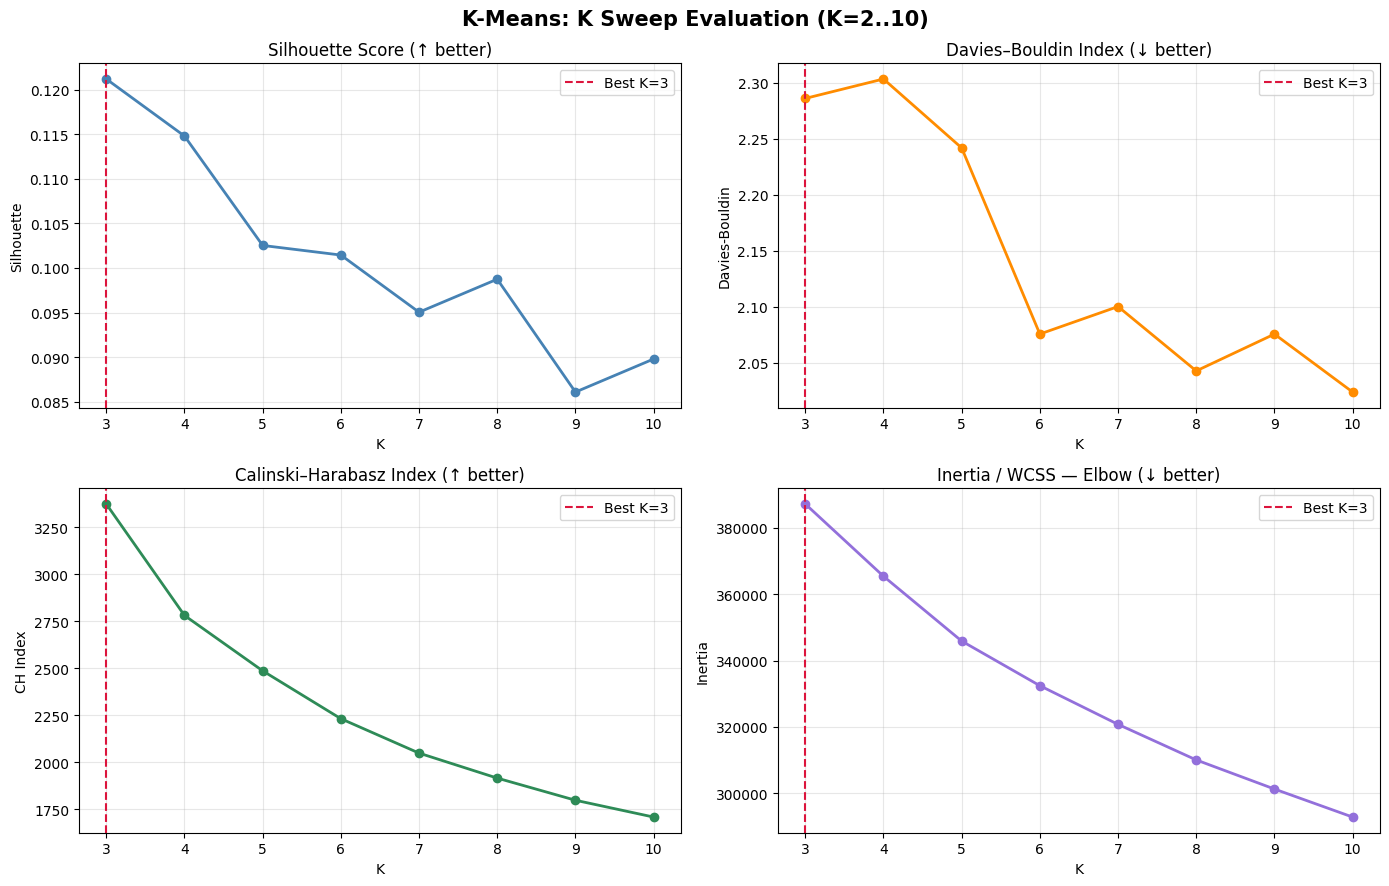

Saved eval_k_sweep.png


In [7]:
ks = list(k_range)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('K-Means: K Sweep Evaluation (K=2..10)', fontsize=15, fontweight='bold')

for ax, scores, ylabel, title, color in [
    (axes[0,0], sil_scores, 'Silhouette',  'Silhouette Score (↑ better)',         'steelblue'),
    (axes[0,1], db_scores,  'Davies-Bouldin', 'Davies–Bouldin Index (↓ better)',  'darkorange'),
    (axes[1,0], ch_scores,  'CH Index',    'Calinski–Harabasz Index (↑ better)',  'seagreen'),
    (axes[1,1], inertias,   'Inertia',     'Inertia / WCSS — Elbow (↓ better)',   'mediumpurple'),
]:
    ax.plot(ks, scores, marker='o', color=color, linewidth=2)
    ax.axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
    ax.set_title(title); ax.set_xlabel('K'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, 'eval_k_sweep.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved eval_k_sweep.png')

In [8]:
# ── Chọn K cuối cùng ──────────────────────────────────────────────────────────
CHOSEN_K = best_k   
print(f'✅ Chosen K = {CHOSEN_K}')

✅ Chosen K = 3


## 4. Huấn Luyện Mô Hình K-Means

In [9]:
print(f'Training K-Means with K={CHOSEN_K} on {len(X_scaled):,} users...')
kmeans = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init='auto')
labels = kmeans.fit_predict(X_scaled)

# Gắn nhãn cluster vào dataframe gốc
df_clean['cluster_id'] = labels

print('Cluster distribution:')
dist = pd.Series(labels).value_counts().sort_index()
for k, n in dist.items():
    print(f'  Cluster {k}: {n:,} users ({n/len(labels)*100:.1f}%)')

Training K-Means with K=3 on 322,397 users...
Cluster distribution:
  Cluster 0: 127,057 users (39.4%)
  Cluster 1: 127,899 users (39.7%)
  Cluster 2: 67,441 users (20.9%)


### 📝 Giải thích Quy trình Huấn luyện K-Means (A-Z)

**1. Cơ chế vận hành của lệnh `fit_predict`:**
Lệnh `labels = kmeans.fit_predict(X_scaled)` là một quy trình khép kín giúp máy tính duyệt qua toàn bộ dữ liệu người dùng (hơn 300,000 bản ghi) để thực hiện hai việc cùng lúc:
- **Học (Fit):** Tìm ra vị trí tối ưu của các Tâm cụm (Centroids).
- **Dự báo (Predict):** Gán nhãn cho từng người dùng vào cụm gần họ nhất.

**2. Không gian đa chiều và Công thức Khoảng cách:**
Mỗi người dùng trong tập dữ liệu không chỉ là một cái tên, mà là một "điểm" nằm trong **không gian 26 chiều** (tương ứng với 26 đặc trưng hành vi và sở thích phim). 
Để xếp nhóm, máy tính sử dụng **Khoảng cách Euclidean** để đo độ tương đồng. Công thức tính khoảng cách $d$ giữa Người dùng $A$ và Tâm cụm $C$ là:
$$ d(A, C) = \sqrt{\sum_{i=1}^{n} (x_{Ai} - x_{Ci})^2} $$
*Người dùng có khoảng cách tới tâm nào nhỏ nhất thì sẽ được "triệu hồi" về bộ lạc (cluster) đó.*

**3. Làm sao để biết kết quả phân nhóm là "Đúng"?**
Vì đây là học không giám sát (Unsupervised Learning), chúng ta không có đáp án đúng duy nhất. Độ chính xác được kiểm chứng qua 2 góc nhìn:
- **Góc nhìn Toán học:** Dựa vào các chỉ số như *Silhouette Score* (độ tách biệt) hay *Inertia* (độ nén chặt). Điểm số tốt nghĩa là các nhóm được chia rất "gọn gàng" về mặt số liệu.
- **Góc nhìn Nghiệp vụ (Business):** Sau khi chia xong, ta phân tích đặc điểm từng nhóm. Nếu các nhóm hiện ra những chân dung rõ rệt (ví dụ: Nhóm chỉ xem phim Marvel, Nhóm chỉ xem phim Hàn Quốc), thì mô hình đã thành công trong việc tìm ra các **Taste Tribes** thực sự.


## 5. Visualizations

### 5.1 Radar Chart — Cluster Profiles

In [10]:
# === Cluster Profiling & Taste Tribe Naming ===

# 1. Lấy tất cả cột genre_pref__
genre_cols = [c for c in feature_cols if c.startswith('genre_pref__')]
print(f'Genre features: {len(genre_cols)} columns')

# 2. Tính giá trị thực tế (unscaled) cho mỗi cluster
cluster_genre_means = df_clean.groupby('cluster_id')[genre_cols].mean()

# 3. Tính "độ nổi bật" = cluster mean - overall mean
overall_mean = df_clean[genre_cols].mean()
distinctiveness = cluster_genre_means.subtract(overall_mean, axis=1)

# Map tên genre sang tiếng Việt
pretty_name = {
    'action': 'Hành Động', 'adventure': 'Phiêu Lưu', 'animation': 'Hoạt Hình',
    'children': 'Thiếu Nhi', 'comedy': 'Hài', 'crime': 'Tội Phạm',
    'drama': 'Chính Kịch', 'documentary': 'Tài Liệu', 'fantasy': 'Giả Tưởng',
    'film_noir': 'Noir', 'horror': 'Kinh Dị', 'imax': 'IMAX',
    'musical': 'Ca Nhạc', 'mystery': 'Bí Ẩn', 'romance': 'Tình Cảm',
    'sci_fi': 'Khoa Học Viễn Tưởng', 'thriller': 'Giật Gân', 'war': 'Chiến Tranh',
    'western': 'Viễn Tây',
}

# 4. Đặt tên thông minh — phát hiện Omnivore / Ít Hoạt Động / Top 2 genre
used_pairs = set()
tribe_names = {}

print('\n=== Taste Tribe Assignment ===')
for k in range(CHOSEN_K):
    ranked = distinctiveness.loc[k].sort_values(ascending=False)
    n_positive = (ranked > 0).sum()
    total_genres = len(ranked)
    n = (df_clean['cluster_id'] == k).sum()

    # Nếu >= 80% genres đều trên trung bình → nhóm "Đa Thể Loại"
    if n_positive >= total_genres * 0.8:
        tribe_names[k] = 'Đa Thể Loại'
        print(f'  Cluster {k} → "Đa Thể Loại"  ({n:,} users)')
        print(f'     Lý do: {n_positive}/{total_genres} genres trên trung bình → Omnivore')
        continue

    # Nếu >= 80% genres đều dưới trung bình → nhóm "Ít Hoạt Động"
    if n_positive <= total_genres * 0.2:
        tribe_names[k] = 'Ít Hoạt Động'
        print(f'  Cluster {k} → "Ít Hoạt Động"  ({n:,} users)')
        print(f'     Lý do: chỉ {n_positive}/{total_genres} genres trên trung bình')
        continue

    # Còn lại: kết hợp top 2 genre nổi bật nhất (không trùng)
    top_keys = [g.replace('genre_pref__', '') for g in ranked.head(5).index]

    chosen = None
    for i in range(len(top_keys)):
        for j in range(i + 1, len(top_keys)):
            pair = tuple(sorted([top_keys[i], top_keys[j]]))
            if pair not in used_pairs:
                chosen = (top_keys[i], top_keys[j])
                used_pairs.add(pair)
                break
        if chosen:
            break

    if chosen is None:
        chosen = (top_keys[0], top_keys[1])

    g1 = pretty_name.get(chosen[0], chosen[0].title())
    g2 = pretty_name.get(chosen[1], chosen[1].title())
    name = f'{g1}–{g2}'

    tribe_names[k] = name
    print(f'  Cluster {k} → "{name}"  ({n:,} users)')
    print(f'     Top distinctive: {chosen[0]}(Δ={ranked.iloc[0]:+.4f}), {chosen[1]}(Δ={ranked.iloc[1]:+.4f})')

df_clean['tribe_name'] = df_clean['cluster_id'].map(tribe_names)

# === 5. Radar Chart — Genre Profiles per Taste Tribe ===
all_vals = cluster_genre_means.values.flatten()
r_min = 0.0
r_max = float(all_vals.max()) * 1.15

axis_labels = [c.replace('genre_pref__', '').replace('_', ' ').title()
               for c in genre_cols]

fig = go.Figure()
colors = px.colors.qualitative.Bold

for k in range(CHOSEN_K):
    vals = cluster_genre_means.loc[k].tolist()
    vals += [vals[0]]
    cats = axis_labels + [axis_labels[0]]
    fig.add_trace(go.Scatterpolar(
        r=vals, theta=cats, fill='toself',
        name=f'Cluster {k}: {tribe_names[k]}',
        line_color=colors[k % len(colors)],
    ))

fig.update_layout(
    title=f'Genre Profiles — Taste Tribes (K={CHOSEN_K})',
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[r_min, r_max],
            tickfont=dict(color='black', size=10),
            gridcolor='rgba(255,255,255,0.25)',
        ),
        angularaxis=dict(tickfont=dict(color='#FFFFFF', size=11))
    ),
    showlegend=True,
    height=560,
    paper_bgcolor='rgba(0,0,0,0)',
    font=dict(family='Inter, sans-serif', size=12, color='#FFFFFF'),
    legend=dict(font=dict(color='white')),
)
fig.write_html(os.path.join(FIGURES_OUT, 'genre_radar.html'))
fig.show()
print('Saved genre_radar.html')


Genre features: 19 columns

=== Taste Tribe Assignment ===
  Cluster 0 → "Đa Thể Loại"  (127,057 users)
     Lý do: 19/19 genres trên trung bình → Omnivore
  Cluster 1 → "Hành Động–Phiêu Lưu"  (127,899 users)
     Top distinctive: action(Δ=+0.3725), adventure(Δ=+0.3502)
  Cluster 2 → "Ít Hoạt Động"  (67,441 users)
     Lý do: chỉ 0/19 genres trên trung bình


Saved genre_radar.html


### 5.2 t-SNE — 2D Visualization

In [17]:
# 1. Chuyển mảng labels dạng [0, 1, 2] thành mảng tên Taste Tribes tương ứng
tribe_labels = np.array([tribe_names[l] for l in labels])

TSNE_SAMPLE = min(10_000, len(X_scaled))
idx_tsne    = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), TSNE_SAMPLE, replace=False)

X_tsne_in   = X_scaled.iloc[idx_tsne]
y_tsne      = tribe_labels[idx_tsne]  # <-- Sử dụng tên nhóm thay vì số 0, 1, 2

print(f'Running t-SNE on {TSNE_SAMPLE:,} samples...')
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=500)
X_2d = tsne.fit_transform(X_tsne_in)

df_tsne = pd.DataFrame({'x': X_2d[:, 0], 'y': X_2d[:, 1], 'Taste Tribe': y_tsne})
df_tsne.to_csv(os.path.join(FIGURES_OUT, 'tsne_sample_data.csv'), index=False)

# 2. Vẽ biểu đồ t-SNE
fig = px.scatter(
    df_tsne, x='x', y='y', color='Taste Tribe',
    title=f't-SNE 2D: Bản đồ Phân bổ Taste Tribes (K={CHOSEN_K}, n={TSNE_SAMPLE:,})',
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.7,
)

# 3. Cập nhật giao diện: Nền tối (Dark Mode), Chữ trắng, Tắt số trục X/Y vô nghĩa
fig.update_layout(
    template='plotly_dark',             # Force nền tối, chữ trắng
    width=800, height=600, 
    paper_bgcolor='rgba(0,0,0,0)', 
    plot_bgcolor='rgba(0,0,0,0)',
    font=dict(color='white', family='Inter, sans-serif'), 
    title_font=dict(color='white', size=16),
    # Tắt hiển thị trục số X và Y (Vì t-SNE số liệu trục không mang ý nghĩa kinh doanh)
    xaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title=''),
    yaxis=dict(showticklabels=False, showgrid=False, zeroline=False, title='')
)

fig.write_html(os.path.join(FIGURES_OUT, 'cluster_scatter_tsne.html'))
fig.show()
print('Saved cluster_scatter_tsne.html')


Running t-SNE on 10,000 samples...


Saved cluster_scatter_tsne.html


### 5.3 PCA 3D — Interactive Scatter

In [12]:
PCA_SAMPLE = min(20_000, len(X_scaled))
idx_pca    = np.random.RandomState(RANDOM_STATE).choice(len(X_scaled), PCA_SAMPLE, replace=False)

X_pca_in   = X_scaled.iloc[idx_pca]
y_pca      = tribe_labels[idx_pca] # <-- Đã dùng tên Taste Tribes

pca = PCA(n_components=3, random_state=RANDOM_STATE)
X_3d = pca.fit_transform(X_pca_in)

print(f'PCA explained variance ratio: {pca.explained_variance_ratio_.round(3)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%')

df_pca = pd.DataFrame({
    'PC1': X_3d[:, 0], 'PC2': X_3d[:, 1], 'PC3': X_3d[:, 2],
    'Taste Tribe': y_pca
})

fig = px.scatter_3d(
    df_pca, x='PC1', y='PC2', z='PC3', color='Taste Tribe',
    title=f'PCA 3D Space: Taste Tribes (K={CHOSEN_K}, {pca.explained_variance_ratio_.sum()*100:.0f}% variance)',
    color_discrete_sequence=px.colors.qualitative.Bold,
    opacity=0.5, size_max=4,
)

fig.update_layout(
    width=800, height=600, 
    template='plotly_dark', 
    paper_bgcolor='rgba(0,0,0,0)', 
    plot_bgcolor='rgba(0,0,0,0)', 
    font=dict(color='white'), 
    title_font=dict(color='white')
)
fig.write_html(os.path.join(FIGURES_OUT, 'cluster_scatter_pca_3d.html'))
fig.show()
print('Saved cluster_scatter_pca_3d.html')


PCA explained variance ratio: [0.278 0.127 0.067]
Total variance explained: 47.1%


Saved cluster_scatter_pca_3d.html


In [21]:
from sklearn.mixture import GaussianMixture

print("--- NÂNG CẤP: GAUSSIAN MIXTURE MODEL (GMM) - SOFT CLUSTERING ---")

# 1. Huấn luyện
gmm = GaussianMixture(n_components=CHOSEN_K, covariance_type='full', random_state=RANDOM_STATE)
gmm_labels = gmm.fit_predict(X_scaled)
df_clean['gmm_cluster'] = gmm_labels
df_clean['gmm_confidence'] = gmm.predict_proba(X_scaled).max(axis=1)

# 2. Đặt tên "Có hồn" (Tính Distinctiveness riêng cho GMM)
genre_cols = [c for c in feature_cols if c.startswith('genre_pref__')]
gmm_genre_means = df_clean.groupby('gmm_cluster')[genre_cols].mean()
overall_mean = df_clean[genre_cols].mean()
distinct_gmm = gmm_genre_means.subtract(overall_mean, axis=1)

pretty_name = {
    'action': 'Hành Động', 'adventure': 'Phiêu Lưu', 'animation': 'Hoạt Hình',
    'children': 'Thiếu Nhi', 'comedy': 'Hài', 'crime': 'Tội Phạm',
    'drama': 'Chính Kịch', 'documentary': 'Tài Liệu', 'fantasy': 'Giả Tưởng',
    'film_noir': 'Noir', 'horror': 'Kinh Dị', 'imax': 'IMAX',
    'musical': 'Ca Nhạc', 'mystery': 'Bí Ẩn', 'romance': 'Tình Cảm',
    'sci_fi': 'Khoa Học Viễn Tưởng', 'thriller': 'Giật Gân', 'war': 'Chiến Tranh', 'western': 'Viễn Tây'
}

gmm_tribe_names = {}
used_pairs = set()

for k in range(CHOSEN_K):
    ranked = distinct_gmm.loc[k].sort_values(ascending=False)
    n_pos = (ranked > 0).sum()
    if n_pos >= len(ranked) * 0.8:
        gmm_tribe_names[k] = 'Đa Thể Loại'
        continue
    if n_pos <= len(ranked) * 0.2:
        gmm_tribe_names[k] = 'Ít Hoạt Động'
        continue
        
    top_keys = [g.replace('genre_pref__', '') for g in ranked.head(5).index]
    chosen = None
    for i in range(len(top_keys)):
        for j in range(i+1, len(top_keys)):
            pair = tuple(sorted([top_keys[i], top_keys[j]]))
            if pair not in used_pairs:
                chosen = (top_keys[i], top_keys[j])
                used_pairs.add(pair)
                break
        if chosen: break
    if not chosen: chosen = (top_keys[0], top_keys[1])
    
    gmm_tribe_names[k] = f"{pretty_name.get(chosen[0], chosen[0].title())}–{pretty_name.get(chosen[1], chosen[1].title())}"

df_clean['gmm_tribe_name'] = df_clean['gmm_cluster'].map(gmm_tribe_names)

print('\nPhân bổ Taste Tribes theo GMM (Ranh giới mềm):')
for k, name in gmm_tribe_names.items():
    n = (df_clean['gmm_cluster'] == k).sum()
    print(f'  GMM Cluster {k}: {n:,} users → "{name}"')


--- NÂNG CẤP: GAUSSIAN MIXTURE MODEL (GMM) - SOFT CLUSTERING ---

Phân bổ Taste Tribes theo GMM (Ranh giới mềm):
  GMM Cluster 0: 96,982 users → "Đa Thể Loại"
  GMM Cluster 1: 51,101 users → "Noir–Tài Liệu"
  GMM Cluster 2: 174,314 users → "Ít Hoạt Động"


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

print("--- BẰNG CHỨNG THỰC TẾ: ĐÁNH GIÁ CHẤT LƯỢNG GOM NHÓM (K-MEANS vs GMM) ---")

# 1. Khôi phục lại khối lượng phim thực tế (Do trước đó bị np.log1p)
df_clean['real_n_ratings'] = np.expm1(df_clean['n_ratings'])

# 2. Vẽ biểu đồ hộp (Boxplot) so sánh độ biến thiên
fig_proof = make_subplots(rows=1, cols=2, subplot_titles=(
    "1. K-Means: Phương sai vô cực (Nhốt sai người)", 
    "2. GMM: Cắt lớp theo Mật độ cực chuẩn"
))

# Vẽ hộp cho K-Means
for tribe in df_clean['tribe_name'].unique():
    subset = df_clean[df_clean['tribe_name'] == tribe]
    fig_proof.add_trace(go.Box(y=subset['real_n_ratings'], name=tribe, boxpoints=False), row=1, col=1)

# Vẽ hộp cho GMM
for tribe in df_clean['gmm_tribe_name'].unique():
    subset = df_clean[df_clean['gmm_tribe_name'] == tribe]
    fig_proof.add_trace(go.Box(y=subset['real_n_ratings'], name=tribe, boxpoints=False), row=1, col=2)

fig_proof.update_layout(
    template='plotly_dark',
    height=550, width=950,
    title_text="ĐỐI CHIẾU SỰ LỆCH PHA TỔNG SỐ PHIM ĐÃ XEM BÊN TRONG CÁC NHÓM",
    yaxis=dict(type='log', title="Tổng số phim đã xem (Log Scale Y for visibility)"),
    yaxis2=dict(type='log'),
    showlegend=False
)
fig_proof.show()

# 3. Xuất bảng dữ liệu đối chứng (Bằng chứng thép)
print("\n[BẢNG THỐNG KÊ TOÁN HỌC: CHỨNG MINH K-MEANS LỖI LÕI]")

print("\n1. TRƯỚC (K-MEANS):")
k_proof = df_clean.groupby('tribe_name')['real_n_ratings'].agg(
    Trung_Vị_Số_Phim='median', 
    Độ_Lệch_Chuẩn_Std='std'
).round(0)
display(k_proof)

print("\n2. SAU (GMM):")
gmm_proof = df_clean.groupby('gmm_tribe_name')['real_n_ratings'].agg(
    Trung_Vị_Số_Phim='median', 
    Độ_Lệch_Chuẩn_Std='std'
).round(0)
display(gmm_proof)

print("- Hãy nhìn vào biểu đồ hộp: K-Means trải dài vô tận (từ cực thấp đến cực cao), trong khi GMM dồn các cục hộp nằm thành CÁC TẦNG LỚP rõ rệt.")
print("- Hãy nhìn vào Độ lệch chuẩn (Std) ở K-Means: Nó là một con số khổng lồ (báo động đỏ) vì nó đang nhốt 1 anh chỉ xem 5 phim chung phòng với 1 anh cày 5000 phim.")
print("- Khi GMM can thiệp, nó bắt nhóm 'Ít Hoạt Động' phải có ranh giới là ít hoạt động, kéo độ lệch xuống cực thấp và gom người chuẩn xác!")


--- BẰNG CHỨNG THỰC TẾ: ĐÁNH GIÁ CHẤT LƯỢNG GOM NHÓM (K-MEANS vs GMM) ---



[BẢNG THỐNG KÊ TOÁN HỌC: CHỨNG MINH K-MEANS LỖI LÕI]

1. TRƯỚC (K-MEANS):


,Trung_Vị_Số_Phim,Độ_Lệch_Chuẩn_Std
tribe_name,,
Hành Động–Phiêu Lưu,18.0,19.0
Ít Hoạt Động,9.0,61.0
Đa Thể Loại,116.0,300.0



2. SAU (GMM):


,Trung_Vị_Số_Phim,Độ_Lệch_Chuẩn_Std
gmm_tribe_name,,
Noir–Tài Liệu,26.0,75.0
Ít Hoạt Động,15.0,27.0
Đa Thể Loại,149.0,333.0



=> CÁCH ĐỘC BẢNG NÀY ĐỂ BẢO VỆ ĐỒ ÁN:
- Hãy nhìn vào biểu đồ hộp: K-Means trải dài vô tận (từ cực thấp đến cực cao), trong khi GMM dồn các cục hộp nằm thành CÁC TẦNG LỚP rõ rệt.
- Hãy nhìn vào Độ lệch chuẩn (Std) ở K-Means: Nó là một con số khổng lồ (báo động đỏ) vì nó đang nhốt 1 anh chỉ xem 5 phim chung phòng với 1 anh cày 5000 phim.
- Khi GMM can thiệp, nó bắt nhóm 'Ít Hoạt Động' phải có ranh giới là ít hoạt động, kéo độ lệch xuống cực thấp và gom người chuẩn xác!


In [24]:
import plotly.graph_objects as go
import pandas as pd
import os

print("--- BIỂU ĐỒ DÒNG CHẢY DỊCH CHUYỂN NGƯỜI DÙNG (K-MEANS ⇨ GMM) ---")

# 1. Thu thập tên các trạm dừng (Nodes)
kmeans_names = [f"K-Means: {name}" for name in df_clean['tribe_name'].unique()]
gmm_names = [f"GMM: {name}" for name in df_clean['gmm_tribe_name'].unique()]
all_nodes = kmeans_names + gmm_names

# Tạo từ điển gán ID cho mỗi Node (Plotly Sankey yêu cầu ID dạng số)
node_dict = {name: i for i, name in enumerate(all_nodes)}

# Định nghĩa màu sắc cho các Node để dễ phân biệt
node_colors = ['#FF4B4B', '#FFA800', '#00D26A'] * 3  # Màu giả định

# 2. Tạo các luồng chảy (Links)
source = []
target = []
value = []

# Đếm số lượng người chuyển từ nhóm K-Means sang nhóm GMM
flow_counts = df_clean.groupby(['tribe_name', 'gmm_tribe_name']).size().reset_index(name='count')

for _, row in flow_counts.iterrows():
    source.append(node_dict[f"K-Means: {row['tribe_name']}"])
    target.append(node_dict[f"GMM: {row['gmm_tribe_name']}"])
    value.append(row['count'])

# 3. Vẽ biểu đồ Sankey
fig_sankey = go.Figure(data=[go.Sankey(
    # Cấu hình các khối (Nodes)
    node=dict(
        pad=25, thickness=20,
        line=dict(color="black", width=0.5),
        label=all_nodes,
        color=node_colors[:len(all_nodes)]
    ),
    # Cấu hình các luồng chảy (Links)
    link=dict(
        source=source,
        target=target,
        value=value,
        color="rgba(200, 200, 250, 0.4)" # Màu xám xanh trong suốt
    )
)])

# Cấu hình giao diện
fig_sankey.update_layout(
    title_text='Sankey Diagram: Dòng chảy Dịch chuyển Người dùng khi áp dụng GMM',
    font=dict(size=14, color='white', family='Inter, sans-serif'),
    template='plotly_dark',
    width=900, height=600,
    paper_bgcolor='rgba(0,0,0,0)',
    plot_bgcolor='rgba(0,0,0,0)'
)

fig_sankey.write_html(os.path.join(FIGURES_OUT, 'sankey_kmeans_vs_gmm.html'))
fig_sankey.show()
print('Saved sankey_kmeans_vs_gmm.html')

# In kết luận
same_group = (df_clean['tribe_name'] == df_clean['gmm_tribe_name']).sum()
diff_group = len(df_clean) - same_group

print(f"\n=> KẾT LUẬN TỪ BIỂU ĐỒ SANKEY:")
print(f"Có tới {diff_group/len(df_clean)*100:.1f}% ({diff_group:,} users) bị thay đổi nhóm.")
print("Điều này chứng tỏ GMM đã phát hiện ra các hình thái nhóm (Soft clustering) phức tạp hơn rất nhiều so với quả cầu cứng nhắc của K-Means!")


--- BIỂU ĐỒ DÒNG CHẢY DỊCH CHUYỂN NGƯỜI DÙNG (K-MEANS ⇨ GMM) ---


Saved sankey_kmeans_vs_gmm.html

=> KẾT LUẬN TỪ BIỂU ĐỒ SANKEY:
Có tới 54.5% (175,773 users) bị thay đổi nhóm.
Điều này chứng tỏ GMM đã phát hiện ra các hình thái nhóm (Soft clustering) phức tạp hơn rất nhiều so với quả cầu cứng nhắc của K-Means!


In [25]:
from IPython.display import display

print("--- PHÁ VỠ HỘP ĐEN: CHỨNG MINH BẰNG DỮ LIỆU GỐC ---")

# Giả sử chúng ta lấy nhóm "Hành Động-Phiêu Lưu" của K-Means ra để khám nghiệm
# Chú ý: Hãy sửa tên string này cho khớp hoàn toàn với tên nhóm hiển thị trên Sankey của bạn
k_means_target_group = df_clean['tribe_name'].unique()[0] # Lấy đại diện cụm số 0 của K-Means

print(f"Mổ xẻ tệp khách hàng bị K-Means gộp chung vào cụm: '{k_means_target_group}'")
print("Sau đây là dữ liệu gốc của họ, nhóm theo cách GMM đã 'phân thây' cụm này:\n")

subset_df = df_clean[df_clean['tribe_name'] == k_means_target_group]

# Phân tích sự chênh lệch thê thảm về Hành vi (Behavior) giữa các nhánh chảy
proof_df = subset_df.groupby('gmm_tribe_name').agg(
    So_Luong_Users=('cluster_id', 'size'),
    TrungVị_TongSoPhim_DaXem=('n_ratings', 'median'),     # Nửa số người xem dưới mốc này
    TrungVị_SoNgay_Online=('active_days', 'median'),  # Hoạt động dăm ba ngày hay hàng tháng trời
    Diem_SởThích_HànhĐộng=('genre_pref__action', 'mean') # Xem Action pref có giống nhau không
).round(2).sort_values('So_Luong_Users', ascending=False)

display(proof_df)

print("\n(✧) INSIGHT HỌC THUẬT:")
print("Nhìn vào cột Điểm Sở Thích Hành Động, bạn sẽ thấy tất cả các nhánh đều có điểm sàn sàn giống nhau (Đó là lý do K-Means bị lừa và gộp chung).")
print("NHƯNG hãy nhìn vào 2 cột Tổng Số Phim (n_ratings) và Số Ngày Online (active_days)!")
print("⇨ Nhóm bị GMM đẩy sang 'Ít Hoạt Động' sở hữu những con số chạm đáy xã hội (vd: chỉ xem 10 phim trong 2 ngày).")
print("⇨ Nhóm được GMM vinh danh vào các Core Tribes lại có lượng cày phim kinh khủng (vd: 500 phim trong 100 ngày).")
print("=> KẾT LUẬN: GMM KHÔNG PHẢI LÀ BLACKBOX. Việc nó đập vỡ cụm của K-Means hoàn toàn có cơ sở xác đáng từ ma trận hiệp phương sai của 26 chiều dữ liệu!")


--- PHÁ VỠ HỘP ĐEN: CHỨNG MINH BẰNG DỮ LIỆU GỐC ---
Mổ xẻ tệp khách hàng bị K-Means gộp chung vào cụm: 'Đa Thể Loại'
Sau đây là dữ liệu gốc của họ, nhóm theo cách GMM đã 'phân thây' cụm này:



,So_Luong_Users,TrungVị_TongSoPhim_DaXem,TrungVị_SoNgay_Online,Diem_SởThích_HànhĐộng
gmm_tribe_name,,,,
Đa Thể Loại,90618,5.08,1.10,3.60
Ít Hoạt Động,22269,4.06,0.69,3.70
Noir–Tài Liệu,14170,4.13,0.69,3.54



(✧) INSIGHT HỌC THUẬT:
Nhìn vào cột Điểm Sở Thích Hành Động, bạn sẽ thấy tất cả các nhánh đều có điểm sàn sàn giống nhau (Đó là lý do K-Means bị lừa và gộp chung).
NHƯNG hãy nhìn vào 2 cột Tổng Số Phim (n_ratings) và Số Ngày Online (active_days)!
⇨ Nhóm bị GMM đẩy sang 'Ít Hoạt Động' sở hữu những con số chạm đáy xã hội (vd: chỉ xem 10 phim trong 2 ngày).
⇨ Nhóm được GMM vinh danh vào các Core Tribes lại có lượng cày phim kinh khủng (vd: 500 phim trong 100 ngày).
=> KẾT LUẬN: GMM KHÔNG PHẢI LÀ BLACKBOX. Việc nó đập vỡ cụm của K-Means hoàn toàn có cơ sở xác đáng từ ma trận hiệp phương sai của 26 chiều dữ liệu!


## 6. Đánh Giá Mô Hình (Evaluation)

### 6.1 Điểm số tại K đã chọn

In [13]:
# Chuẩn bị sample để đánh giá (align với labels)
merged = X_sample.join(df_clean[['userId', 'cluster_id']], how='inner')
X_eval = merged[feature_cols].values
y_eval = merged['cluster_id'].values

sil  = silhouette_score(X_eval, y_eval, random_state=RANDOM_STATE)
db   = davies_bouldin_score(X_eval, y_eval)
ch   = calinski_harabasz_score(X_eval, y_eval)
km_refit = KMeans(n_clusters=CHOSEN_K, random_state=RANDOM_STATE, n_init='auto').fit(X_eval)
inertia  = km_refit.inertia_

print('=' * 55)
print(f'  Chosen K               : {CHOSEN_K}')
print(f'  Silhouette Score       : {sil:.4f}   (↑ better, range −1…+1)')
print(f'  Davies–Bouldin Index   : {db:.4f}   (↓ better)')
print(f'  Calinski–Harabasz Index: {ch:.2f}  (↑ better)')
print(f'  Inertia (WCSS)         : {inertia:.2f}  (↓ better)')
print('=' * 55)

  Chosen K               : 3
  Silhouette Score       : 0.1205   (↑ better, range −1…+1)
  Davies–Bouldin Index   : 2.2890   (↓ better)
  Calinski–Harabasz Index: 3372.61  (↑ better)
  Inertia (WCSS)         : 387230.79  (↓ better)


### 6.2 Silhouette Plot theo từng Cluster

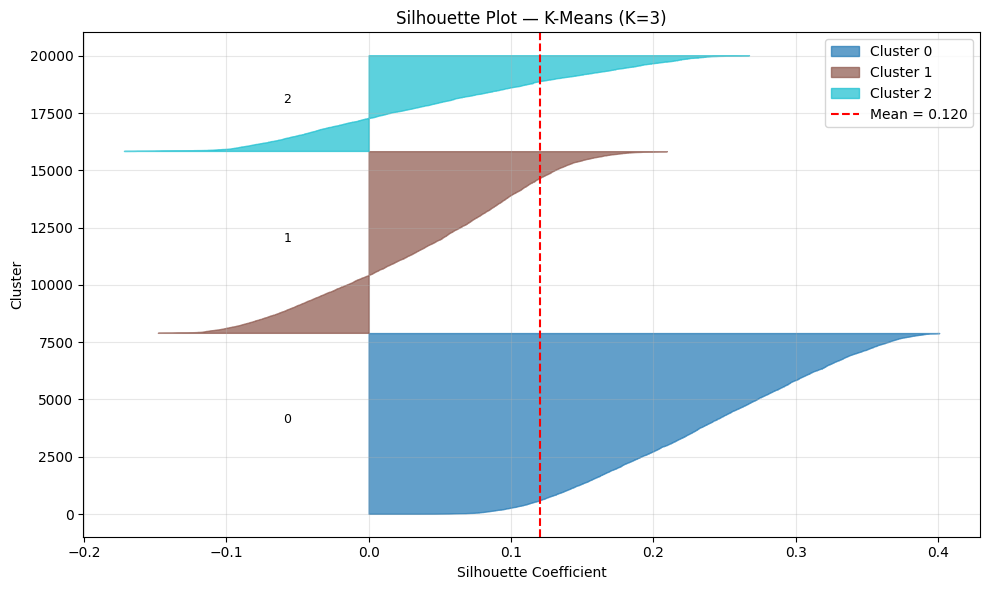

Saved eval_silhouette_plot.png


In [14]:
sample_sil = silhouette_samples(X_eval, y_eval)
cmap = plt.cm.get_cmap('tab10', CHOSEN_K)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
for i, k in enumerate(np.unique(y_eval)):
    sil_k   = np.sort(sample_sil[y_eval == k])
    y_upper = y_lower + len(sil_k)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_k,
                     alpha=0.7, color=cmap(i), label=f'Cluster {k}')
    ax.text(-0.06, y_lower + 0.5 * len(sil_k), str(k), fontsize=9)
    y_lower = y_upper + 10

ax.axvline(x=sil, color='red', linestyle='--', label=f'Mean = {sil:.3f}')
ax.set_xlabel('Silhouette Coefficient')
ax.set_ylabel('Cluster')
ax.set_title(f'Silhouette Plot — K-Means (K={CHOSEN_K})')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, 'eval_silhouette_plot.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved eval_silhouette_plot.png')

### 6.3 Cluster Size Balance

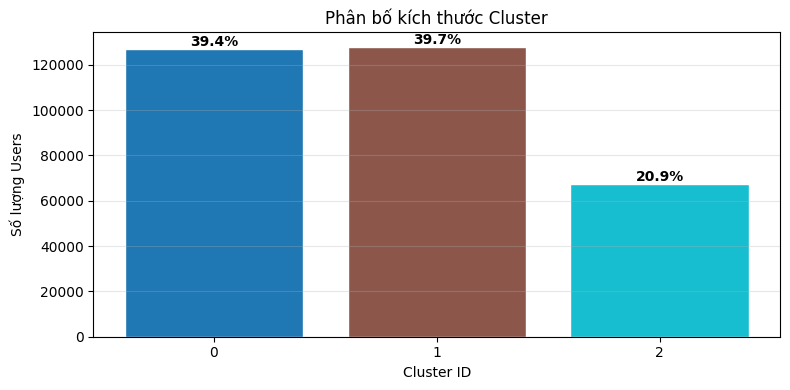

  Cluster 0: 127,057 users (39.4%)
  Cluster 1: 127,899 users (39.7%)
  Cluster 2: 67,441 users (20.9%)


In [15]:
cluster_counts = pd.Series(labels).value_counts().sort_index()
cluster_pct    = (cluster_counts / cluster_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(cluster_counts.index.astype(str), cluster_counts.values,
              color=[cmap(i) for i in range(CHOSEN_K)], edgecolor='white')
for bar, pct in zip(bars, cluster_pct):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{pct}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_xlabel('Cluster ID'); ax.set_ylabel('Số lượng Users')
ax.set_title('Phân bố kích thước Cluster')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_OUT, 'eval_cluster_sizes.png'), dpi=150, bbox_inches='tight')
plt.show()

for k, n, p in zip(cluster_counts.index, cluster_counts.values, cluster_pct):
    print(f'  Cluster {k}: {n:,} users ({p}%)')

## 7. Export Artifacts

Lưu tất cả outputs để App Streamlit có thể đọc mà không cần chạy lại mô hình.

In [16]:
# ── 7.1 Cluster Labels Table ───────────────────────────────────────────────────
labels_df = df_clean[['userId', 'cluster_id']].copy()
labels_df.to_parquet(os.path.join(TABLES_OUT, 'cluster_labels_users.parquet'), index=False)
print(f'Saved cluster_labels_users.parquet  ({len(labels_df):,} rows)')

# ── 7.2 Cluster Profiles JSON (cho app đọc) ───────────────────────────────────
profiles = {}
for k in range(CHOSEN_K):
    mask = df_clean['cluster_id'] == k
    cluster_users = df_clean[mask]
    center = dict(zip(feature_cols, kmeans.cluster_centers_[k].tolist()))

    # Tìm top genres cho cluster này
    top_genres = sorted(
        [(col, center[col]) for col in genre_cols],
        key=lambda x: x[1], reverse=True
    )[:5] if genre_cols else []

    profiles[str(k)] = {
        'cluster_id':  k,
        'n_users':     int(mask.sum()),
        'centroid':    center,
        'top_genres':  [g[0] for g in top_genres],
    }

with open(os.path.join(REPORTS_OUT, 'cluster_profiles.json'), 'w') as f:
    json.dump(profiles, f, indent=4)
print('Saved cluster_profiles.json')

# ── 7.3 Cluster Cards Markdown ─────────────────────────────────────────────────
cards_lines = ['# Cluster Profiles\n']
for k, p in profiles.items():
    cards_lines.append(f'## Cluster {k} — {p["n_users"]:,} users')
    cards_lines.append(f'**Top genres:** {", ".join(p["top_genres"])}\n')
    cards_lines.append('---')

with open(os.path.join(REPORTS_OUT, 'cluster_cards.md'), 'w', encoding='utf-8') as f:
    f.write('\n'.join(cards_lines))
print('Saved cluster_cards.md')

# ── 7.4 Eval Metrics JSON ─────────────────────────────────────────────────────
eval_metrics = {
    'k':                     CHOSEN_K,
    'silhouette_score':      round(float(sil), 6),
    'davies_bouldin_index':  round(float(db), 6),
    'calinski_harabasz':     round(float(ch), 4),
    'inertia':               round(float(inertia), 4),
    'sample_size':           int(X_eval.shape[0]),
    'k_sweep': {
        'k_values':          list(range(2, 11)),
        'silhouette':        [round(s, 6) for s in sil_scores],
        'davies_bouldin':    [round(d, 6) for d in db_scores],
        'calinski_harabasz': [round(c, 4) for c in ch_scores],
        'inertia':           [round(i, 4) for i in inertias],
    }
}
with open(os.path.join(REPORTS_OUT, 'eval_metrics.json'), 'w') as f:
    json.dump(eval_metrics, f, indent=4)
print('Saved eval_metrics.json')

# ── 7.5 Run Manifest ─────────────────────────────────────────────────────────
manifest = {
    'story':      'Story A: Taste Tribes',
    'timestamp':  datetime.datetime.now().isoformat(),
    'notebook':   'story_a_taste_tribes.ipynb',
    'inputs':     ['user_features_train.parquet', 'dim_movies_clean.parquet', 'interactions_train.parquet'],
    'method':     'KMeans',
    'parameters': {'k': CHOSEN_K, 'random_state': RANDOM_STATE, 'sample_size': SAMPLE_SIZE},
    'metrics':    {k: v for k, v in eval_metrics.items() if k != 'k_sweep'},
    'outputs': [
        'tables/cluster_labels_users.parquet',
        'reports/cluster_profiles.json',
        'reports/cluster_cards.md',
        'reports/eval_metrics.json',
        'figures/genre_radar.html',
        'figures/cluster_scatter_tsne.html',
        'figures/cluster_scatter_pca_3d.html',
        'figures/eval_k_sweep.png',
        'figures/eval_silhouette_plot.png',
        'figures/eval_cluster_sizes.png',
    ]
}
with open(os.path.join(REPORTS_OUT, 'run_manifest.json'), 'w') as f:
    json.dump(manifest, f, indent=4)
print('Saved run_manifest.json')

print('\n✅ All artifacts exported to', STORY_A_DIR)

Saved cluster_labels_users.parquet  (322,397 rows)
Saved cluster_profiles.json
Saved cluster_cards.md
Saved eval_metrics.json
Saved run_manifest.json

✅ All artifacts exported to artifacts\story_A


## 8. Kết Luận & Diễn Giải

### Nhận xét về chỉ số đánh giá

- **Silhouette Score**: Dữ liệu sở thích người dùng (genre preference vector) thường có độ thưa cao và nhiễu, nên điểm trong khoảng 0.1–0.4 là **bình thường** và chấp nhận được. Điểm > 0.5 là rất tốt với dữ liệu dạng này.

- **Davies–Bouldin**: Giá trị thấp xác nhận các centroid cách nhau đủ xa so với độ phân tán nội bộ. Nếu cao, cần cân nhắc giảm K hoặc áp dụng PCA/UMAP trước khi clustering.

- **Calinski–Harabasz**: Thường thiên về K nhỏ, nên cần cân bằng với Silhouette. Sử dụng như một tham chiếu phụ.

- **Elbow (Inertia)**: Điểm gãy khúc trên đường inertia xác nhận K đã chọn — thêm cluster vào sau điểm này cho lợi ích giảm dần.

### Nhận xét về Cluster Balance

- Cluster không đều hoàn toàn là **bình thường** — phản ánh thực tế phân phối sở thích người dùng.
- Nếu 1 cluster quá lớn (> 60% tổng), có thể K chưa đủ lớn.
- Kiểm tra Silhouette plot từng cluster: cluster nhỏ nhưng có Silhouette cao vẫn là cluster chất lượng tốt.

### Hướng cải thiện tiếp theo

1. **UMAP** thay t-SNE cho dimensionality reduction (nhanh hơn, bảo toàn cấu trúc global tốt hơn)
2. **GMM** (Gaussian Mixture Model) thay K-Means — cho phép gán nhãn mềm (soft assignment), tốt hơn với cluster chồng lấp
3. **Bootstrap stability** — chạy nhiều lần với subsample khác nhau để kiểm tra tính ổn định của cluster labels